In [1]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report
)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [2]:
REVIEWS_PATH = "IMDB_reviews.json"
MOVIE_DETAILS_PATH = "IMDB_movie_details.json"

print("Reviews file exists :", os.path.exists(REVIEWS_PATH))
print("Movie file exists   :", os.path.exists(MOVIE_DETAILS_PATH))

if not os.path.exists(REVIEWS_PATH):
    raise FileNotFoundError(
        f"Could not find {REVIEWS_PATH}. "
        "Place the notebook in the imdb folder."
    )

df = pd.read_json(REVIEWS_PATH, lines=True)

print("\nDataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())


Reviews file exists : True
Movie file exists   : True

Dataset shape: (573913, 7)

Columns:
['review_date', 'movie_id', 'user_id', 'is_spoiler', 'review_text', 'rating', 'review_summary']


,review_date,movie_id,user_id,is_spoiler,review_text,rating,review_summary
0,10 February 2006,tt0111161,ur1898687,True,"In its Oscar year, Shawshank Redemption (writt...",10,A classic piece of unforgettable film-making.
1,6 September 2000,tt0111161,ur0842118,True,The Shawshank Redemption is without a doubt on...,10,Simply amazing. The best film of the 90's.
2,3 August 2001,tt0111161,ur1285640,True,I believe that this film is the best story eve...,8,The best story ever told on film
3,1 September 2002,tt0111161,ur1003471,True,"**Yes, there are SPOILERS here**This film has ...",10,Busy dying or busy living?
4,20 May 2004,tt0111161,ur0226855,True,At the heart of this extraordinary movie is a ...,8,"Great story, wondrously told and acted"


In [3]:
print("Missing values:")
display(df[["review_text", "is_spoiler"]].isnull().sum().to_frame("Missing"))

print("Duplicate rows:", df.duplicated().sum())
print("Dataset shape :", df.shape)

print("\nTarget distribution:")
target_counts = df["is_spoiler"].value_counts().sort_index()
display(target_counts.rename(index={0: "Non-Spoiler", 1: "Spoiler"}).to_frame("Count"))


Missing values:


,Missing
review_text,0
is_spoiler,0


Duplicate rows: 0
Dataset shape : (573913, 7)

Target distribution:


,Count
is_spoiler,
Non-Spoiler,422989
Spoiler,150924


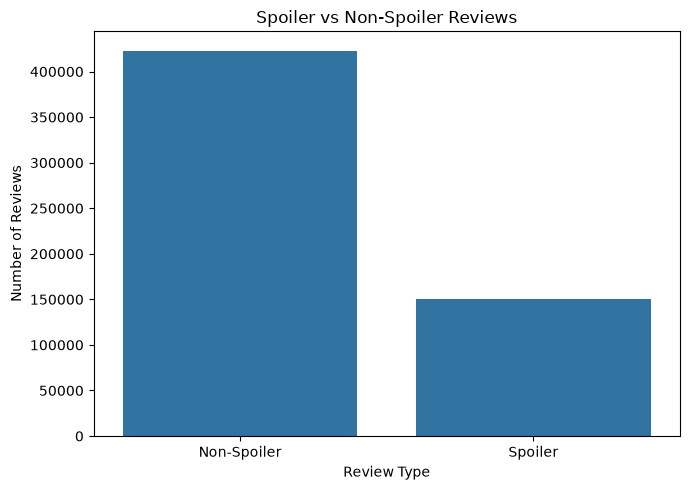

In [4]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="is_spoiler")
plt.title("Spoiler vs Non-Spoiler Reviews")
plt.xlabel("Review Type")
plt.ylabel("Number of Reviews")
plt.xticks([0, 1], ["Non-Spoiler", "Spoiler"])
plt.tight_layout()
plt.show()


In [5]:
df["review_text"] = df["review_text"].fillna("").astype(str)

def clean_text(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)              # HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)  # URLs
    text = re.sub(r"\s+", " ", text)                # extra spaces
    return text.strip()

df["clean_review"] = df["review_text"].apply(clean_text)

print("Original review:")
print(df.loc[0, "review_text"][:500])

print("\nCleaned review:")
print(df.loc[0, "clean_review"][:500])


Original review:
In its Oscar year, Shawshank Redemption (written and directed by Frank Darabont, after the novella Rita Hayworth and the Shawshank Redemption, by Stephen King) was nominated for seven Academy Awards, and walked away with zero. Best Picture went to Forrest Gump, while Shawshank and Pulp Fiction were "just happy to be nominated." Of course hindsight is 20/20, but while history looks back on Gump as a good film, Pulp and Redemption are remembered as some of the all-time best. Pulp, however, was a s

Cleaned review:
in its oscar year, shawshank redemption (written and directed by frank darabont, after the novella rita hayworth and the shawshank redemption, by stephen king) was nominated for seven academy awards, and walked away with zero. best picture went to forrest gump, while shawshank and pulp fiction were "just happy to be nominated." of course hindsight is 20/20, but while history looks back on gump as a good film, pulp and redemption are remembered as some of the al

In [6]:
WORKING_SIZE = min(120_000, len(df))

if len(df) > WORKING_SIZE:
    df_work, _ = train_test_split(
        df,
        train_size=WORKING_SIZE,
        stratify=df["is_spoiler"],
        random_state=42
    )
else:
    df_work = df.copy()

df_work = df_work.reset_index(drop=True)

X = df_work["clean_review"]
y = df_work["is_spoiler"]

print("Working dataset size:", len(df_work))
print("\nClass distribution:")
display(
    y.value_counts(normalize=True)
      .mul(100)
      .round(2)
      .rename(index={0: "Non-Spoiler", 1: "Spoiler"})
      .to_frame("Percentage")
)


Working dataset size: 120000

Class distribution:


,Percentage
is_spoiler,
Non-Spoiler,73.7
Spoiler,26.3


In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print(f"Training samples   : {len(X_train):,}")
print(f"Validation samples : {len(X_val):,}")
print(f"Test samples       : {len(X_test):,}")


Training samples   : 84,000
Validation samples : 18,000
Test samples       : 18,000


In [8]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=100_000,
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents="unicode"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("Training matrix   :", X_train_tfidf.shape)
print("Validation matrix :", X_val_tfidf.shape)
print("Test matrix       :", X_test_tfidf.shape)
print("Vocabulary size   :", len(vectorizer.vocabulary_))


Training matrix   : (84000, 100000)
Validation matrix : (18000, 100000)
Test matrix       : (18000, 100000)
Vocabulary size   : 100000


In [9]:
def evaluate_model(model_name, y_true, y_pred, y_score):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_score),
        "PR-AUC": average_precision_score(y_true, y_score)
    }

results = []


In [10]:
nb_model = MultinomialNB(alpha=0.5)
nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_val_tfidf)
nb_score = nb_model.predict_proba(X_val_tfidf)[:, 1]

nb_result = evaluate_model(
    "Multinomial Naive Bayes",
    y_val, nb_pred, nb_score
)
results.append(nb_result)

display(pd.DataFrame([nb_result]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Multinomial Naive Bayes,0.7612,0.6273,0.2264,0.3328,0.7235,0.5013


In [11]:
lr_model = LogisticRegression(
    C=2.0,
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_val_tfidf)
lr_score = lr_model.predict_proba(X_val_tfidf)[:, 1]

lr_result = evaluate_model(
    "Logistic Regression",
    y_val, lr_pred, lr_score
)
results.append(lr_result)

display(pd.DataFrame([lr_result]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.7764,0.6427,0.3378,0.4428,0.7571,0.5611


In [12]:
svm_model = LinearSVC(
    C=1.5,
    class_weight=None,
    random_state=42
)

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_val_tfidf)
svm_score = svm_model.decision_function(X_val_tfidf)

svm_result = evaluate_model(
    "Linear SVM",
    y_val, svm_pred, svm_score
)
results.append(svm_result)

display(pd.DataFrame([svm_result]).round(4))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Linear SVM,0.7438,0.5168,0.4007,0.4514,0.7116,0.4991


In [13]:
# XGBoost
# TF-IDF is sparse and high-dimensional, so reduce it before using a tree-based model.
svd = TruncatedSVD(n_components=200, random_state=42)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd = svd.transform(X_val_tfidf)

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train_svd, y_train)

xgb_pred = xgb_model.predict(X_val_svd)
xgb_score = xgb_model.predict_proba(X_val_svd)[:, 1]

results.append(evaluate_model("XGBoost", y_val, xgb_pred, xgb_score))
print(classification_report(y_val, xgb_pred))


              precision    recall  f1-score   support

       False       0.78      0.94      0.85     13266
        True       0.60      0.27      0.38      4734

    accuracy                           0.76     18000
   macro avg       0.69      0.60      0.61     18000
weighted avg       0.74      0.76      0.73     18000



In [14]:
results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy", ascending=False)
    .reset_index(drop=True)
)

print("Validation performance:")
display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "PR-AUC": "{:.4f}"
    })
)

best_model_name = results_df.iloc[0]["Model"]
print("\nBest model based on validation accuracy:", best_model_name)


Validation performance:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.7764,0.6427,0.3378,0.4428,0.7571,0.5611
1,XGBoost,0.7616,0.6035,0.2729,0.3759,0.7352,0.5168
2,Multinomial Naive Bayes,0.7612,0.6273,0.2264,0.3328,0.7235,0.5013
3,Linear SVM,0.7438,0.5168,0.4007,0.4514,0.7116,0.4991



Best model based on validation accuracy: Logistic Regression


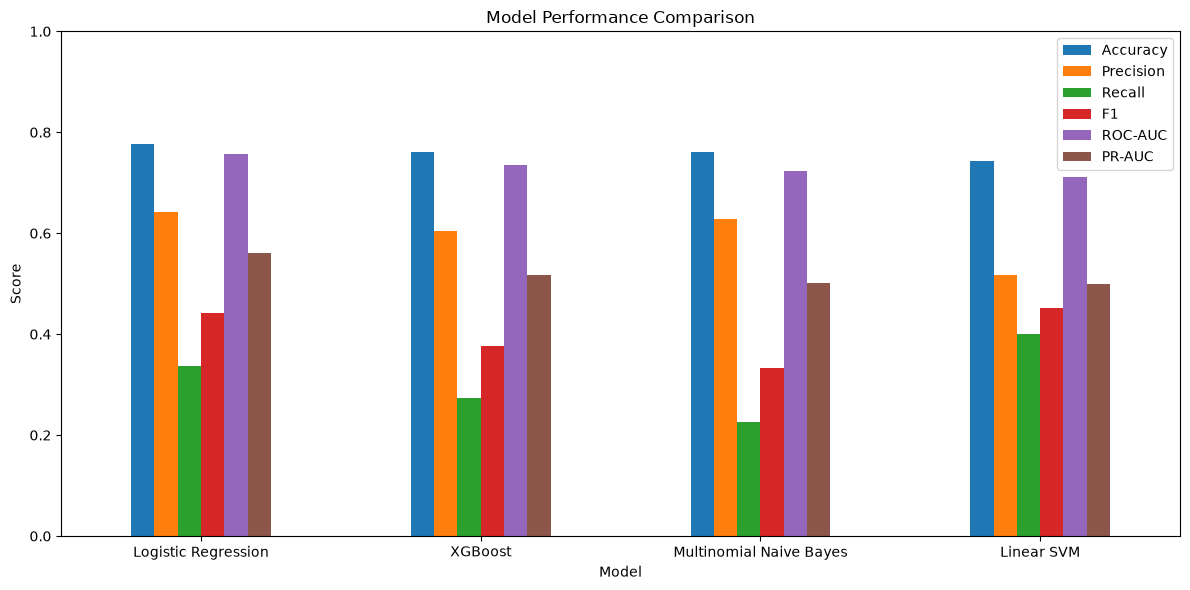

In [15]:
plot_df = results_df.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
]

ax = plot_df.plot(kind="bar", figsize=(12, 6))
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


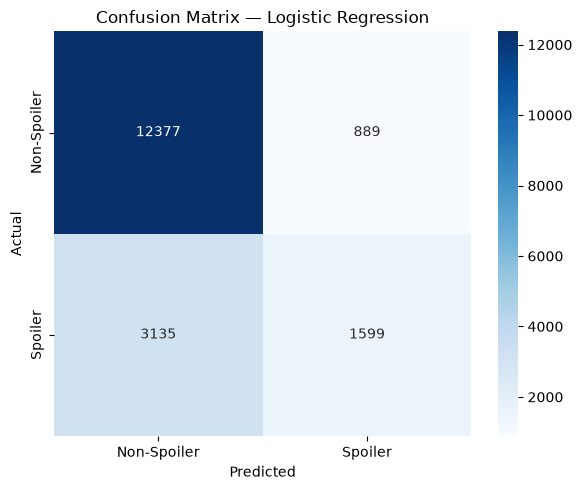

              precision    recall  f1-score   support

 Non-Spoiler     0.7979    0.9330    0.8602     13266
     Spoiler     0.6427    0.3378    0.4428      4734

    accuracy                         0.7764     18000
   macro avg     0.7203    0.6354    0.6515     18000
weighted avg     0.7571    0.7764    0.7504     18000



In [17]:
prediction_map = {
    "Multinomial Naive Bayes": nb_pred,
    "Logistic Regression": lr_pred,
    "Linear SVM": svm_pred,
    "XGBoost": xgb_pred
}

best_pred = prediction_map[best_model_name]

cm = confusion_matrix(y_val, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Spoiler", "Spoiler"],
    yticklabels=["Non-Spoiler", "Spoiler"]
)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(classification_report(
    y_val,
    best_pred,
    target_names=["Non-Spoiler", "Spoiler"],
    digits=4
))


In [19]:
# ============================================
# FINAL TRAINING ON TRAIN + VALIDATION DATA
# ============================================

from xgboost import XGBClassifier

# Combine training and validation data
X_train_final = pd.concat([X_train, X_val])
y_train_final = pd.concat([y_train, y_val])

# Refit TF-IDF on the complete training data
X_train_final_tfidf = vectorizer.fit_transform(X_train_final)
X_test_final_tfidf = vectorizer.transform(X_test)


# ============================================
# SELECT FINAL MODEL
# ============================================

if best_model_name == "Multinomial Naive Bayes":

    final_model = MultinomialNB(alpha=0.5)

    final_model.fit(
        X_train_final_tfidf,
        y_train_final
    )

    test_pred = final_model.predict(
        X_test_final_tfidf
    )

    test_score = final_model.predict_proba(
        X_test_final_tfidf
    )[:, 1]


elif best_model_name == "Logistic Regression":

    final_model = LogisticRegression(
        C=2.0,
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )

    final_model.fit(
        X_train_final_tfidf,
        y_train_final
    )

    test_pred = final_model.predict(
        X_test_final_tfidf
    )

    test_score = final_model.predict_proba(
        X_test_final_tfidf
    )[:, 1]


elif best_model_name == "Linear SVM":

    final_model = LinearSVC(
        C=1.5,
        class_weight=None,
        random_state=42
    )

    final_model.fit(
        X_train_final_tfidf,
        y_train_final
    )

    test_pred = final_model.predict(
        X_test_final_tfidf
    )

    test_score = final_model.decision_function(
        X_test_final_tfidf
    )


elif best_model_name == "XGBoost":

    final_model = XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    final_model.fit(
        X_train_final_tfidf,
        y_train_final
    )

    test_pred = final_model.predict(
        X_test_final_tfidf
    )

    test_score = final_model.predict_proba(
        X_test_final_tfidf
    )[:, 1]


else:
    raise ValueError(
        f"Unknown model: {best_model_name}"
    )


# ============================================
# FINAL TEST EVALUATION
# ============================================

final_result = evaluate_model(
    best_model_name,
    y_test,
    test_pred,
    test_score
)

print("Final test performance:")

display(
    pd.DataFrame([final_result]).round(4)
)

Final test performance:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.7777,0.6482,0.3378,0.4442,0.7626,0.5643


In [20]:
# ============================================
# 5-FOLD STRATIFIED CROSS-VALIDATION
# LOGISTIC REGRESSION + TF-IDF
# ============================================

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Use the combined training + validation data
X_cv = pd.concat(
    [X_train, X_val],
    ignore_index=True
)

y_cv = pd.concat(
    [y_train, y_val],
    ignore_index=True
)

# 5-fold stratified CV
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold, (train_idx, val_idx) in enumerate(
    skf.split(X_cv, y_cv),
    start=1
):

    print(f"\n{'='*50}")
    print(f"FOLD {fold}")
    print(f"{'='*50}")

    # Split text data
    X_fold_train = X_cv.iloc[train_idx]
    X_fold_val = X_cv.iloc[val_idx]

    y_fold_train = y_cv.iloc[train_idx]
    y_fold_val = y_cv.iloc[val_idx]

    # Fit TF-IDF ONLY on fold training data
    fold_vectorizer = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        sublinear_tf=True
    )

    X_fold_train_tfidf = fold_vectorizer.fit_transform(
        X_fold_train
    )

    X_fold_val_tfidf = fold_vectorizer.transform(
        X_fold_val
    )

    # Logistic Regression
    fold_model = LogisticRegression(
        C=2.0,
        max_iter=1000,
        solver="liblinear",
        random_state=42
    )

    fold_model.fit(
        X_fold_train_tfidf,
        y_fold_train
    )

    # Predictions
    fold_pred = fold_model.predict(
        X_fold_val_tfidf
    )

    fold_score = fold_model.predict_proba(
        X_fold_val_tfidf
    )[:, 1]

    # Metrics
    accuracy = accuracy_score(
        y_fold_val,
        fold_pred
    )

    precision = precision_score(
        y_fold_val,
        fold_pred,
        zero_division=0
    )

    recall = recall_score(
        y_fold_val,
        fold_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_fold_val,
        fold_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_fold_val,
        fold_score
    )

    pr_auc = average_precision_score(
        y_fold_val,
        fold_score
    )

    fold_result = {
        "Fold": fold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc
    }

    cv_results.append(fold_result)

    print(
        f"Accuracy : {accuracy:.4f}"
    )
    print(
        f"Precision: {precision:.4f}"
    )
    print(
        f"Recall   : {recall:.4f}"
    )
    print(
        f"F1       : {f1:.4f}"
    )
    print(
        f"ROC-AUC  : {roc_auc:.4f}"
    )
    print(
        f"PR-AUC   : {pr_auc:.4f}"
    )


# ============================================
# CV RESULTS
# ============================================

cv_results_df = pd.DataFrame(cv_results)

print("\n")
print("=" * 70)
print("5-FOLD CROSS-VALIDATION RESULTS")
print("=" * 70)

display(
    cv_results_df.round(4)
)


# ============================================
# MEAN ± STD
# ============================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC-AUC",
    "PR-AUC"
]

cv_summary = pd.DataFrame({
    "Mean": cv_results_df[metrics].mean(),
    "Std": cv_results_df[metrics].std()
})

print("\n")
print("=" * 70)
print("CROSS-VALIDATION SUMMARY")
print("=" * 70)

display(
    cv_summary.round(4)
)


FOLD 1
Accuracy : 0.7788
Precision: 0.6459
Recall   : 0.3519
F1       : 0.4556
ROC-AUC  : 0.7620
PR-AUC   : 0.5650

FOLD 2
Accuracy : 0.7790
Precision: 0.6518
Recall   : 0.3426
F1       : 0.4491
ROC-AUC  : 0.7595
PR-AUC   : 0.5643

FOLD 3
Accuracy : 0.7769
Precision: 0.6421
Recall   : 0.3424
F1       : 0.4466
ROC-AUC  : 0.7595
PR-AUC   : 0.5637

FOLD 4
Accuracy : 0.7705
Precision: 0.6199
Recall   : 0.3292
F1       : 0.4300
ROC-AUC  : 0.7523
PR-AUC   : 0.5527

FOLD 5
Accuracy : 0.7741
Precision: 0.6327
Recall   : 0.3356
F1       : 0.4385
ROC-AUC  : 0.7591
PR-AUC   : 0.5599


5-FOLD CROSS-VALIDATION RESULTS


,Fold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,1,0.7788,0.6459,0.3519,0.4556,0.7620,0.5650
1,2,0.7790,0.6518,0.3426,0.4491,0.7595,0.5643
2,3,0.7769,0.6421,0.3424,0.4466,0.7595,0.5637
3,4,0.7705,0.6199,0.3292,0.4300,0.7523,0.5527
4,5,0.7741,0.6327,0.3356,0.4385,0.7591,0.5599




CROSS-VALIDATION SUMMARY


,Mean,Std
Accuracy,0.7758,0.0036
Precision,0.6385,0.0125
Recall,0.3403,0.0085
F1,0.4440,0.0099
ROC-AUC,0.7585,0.0037
PR-AUC,0.5611,0.0051


In [21]:
# ============================================
# FINAL MODEL TRAINING + UNTOUCHED TEST
# ============================================

# Combine Train + Validation
X_train_final = pd.concat(
    [X_train, X_val],
    ignore_index=True
)

y_train_final = pd.concat(
    [y_train, y_val],
    ignore_index=True
)

print("Final training samples:", len(X_train_final))
print("Final test samples:", len(X_test))


# ============================================
# REFIT TF-IDF ON ALL TRAINING DATA
# ============================================

vectorizer_final = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_final_tfidf = vectorizer_final.fit_transform(
    X_train_final
)

X_test_final_tfidf = vectorizer_final.transform(
    X_test
)

print("Train TF-IDF shape:", X_train_final_tfidf.shape)
print("Test TF-IDF shape :", X_test_final_tfidf.shape)


# ============================================
# FINAL LOGISTIC REGRESSION
# ============================================

final_model = LogisticRegression(
    C=2.0,
    max_iter=1000,
    solver="liblinear",
    random_state=42
)

final_model.fit(
    X_train_final_tfidf,
    y_train_final
)


# ============================================
# TEST PREDICTIONS
# ============================================

test_pred = final_model.predict(
    X_test_final_tfidf
)

test_score = final_model.predict_proba(
    X_test_final_tfidf
)[:, 1]


# ============================================
# FINAL TEST PERFORMANCE
# ============================================

final_result = evaluate_model(
    "Logistic Regression",
    y_test,
    test_pred,
    test_score
)

print("\nFINAL TEST PERFORMANCE")
print("=" * 70)

display(
    pd.DataFrame([final_result]).round(4)
)

Final training samples: 102000
Final test samples: 18000
Train TF-IDF shape: (102000, 50000)
Test TF-IDF shape : (18000, 50000)

FINAL TEST PERFORMANCE


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.7771,0.641,0.3459,0.4493,0.7596,0.5606
